In [1]:
import sys
from pathlib import Path
import os
import scanpy as sc
import numpy as np

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

In [5]:
### PREPROCESS data for benchmarking
from scrna_benchmark.embedding import (
    compute_hvg_subset,
    compute_pca,
    compute_harmony,
    compute_scvi_latent,
    available_representations,
)

adata = sc.read_h5ad("data/PBMC_Stephenson/stephenson_2021_subsampled.h5ad")

# filter to healthy, and subsample to 500 cells per donor
adata = adata[adata.obs["Status"] == "Healthy"].copy()

np.random.seed(42)

cells_to_keep = []

for donor, idx in adata.obs.groupby("patient_id", observed=True).groups.items():
    idx = np.array(list(idx))
    if len(idx) > 500:
        cells_to_keep.extend(np.random.choice(idx, 500, replace=False))
    else:
        cells_to_keep.extend(idx)

adata = adata[cells_to_keep].copy()

print(adata.shape)
print(adata.obs["patient_id"].nunique())

(11290, 16299)
23


In [9]:
# embeddings
adata.raw = adata.copy()

# 1. Keep only 1000 HVGs
adata = compute_hvg_subset(
    adata,
    n_top_genes=1000,
    batch_key="patient_id",
)

# 2. Run PCA with 50 components, but keep 15-dimensional PCA for benchmark
adata = compute_pca(
    adata,
    n_comps=50,
    key_added="X_pca",
    random_state=42,
)

adata.obsm["X_pca_full"] = adata.obsm["X_pca"].copy()
adata.obsm["X_pca"] = adata.obsm["X_pca"][:, :15].copy()

# 3. Run Harmony directly on 15-dimensional PCA
adata = compute_harmony(
    adata,
    batch_col="patient_id",
    basis="X_pca",
    key_added="X_harmony",
    n_comps=None,
)

print("X_scVI" in adata.obsm) # scVI exists in the original h5ad file, so we don't need to compute it here

2026-06-24 10:36:30,713 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
INFO:harmonypy:Running Harmony (PyTorch on cpu)
2026-06-24 10:36:30,716 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-06-24 10:36:30,718 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-06-24 10:36:30,721 - harmonypy - INFO -     max_iter_kmeans: 20
INFO:harmonypy:    max_iter_kmeans: 20
2026-06-24 10:36:30,724 - harmonypy - INFO -     epsilon_cluster: 1e-05
INFO:harmonypy:    epsilon_cluster: 1e-05
2026-06-24 10:36:30,726 - harmonypy - INFO -     epsilon_harmony: 0.0001
INFO:harmonypy:    epsilon_harmony: 0.0001
2026-06-24 10:36:30,729 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-06-24 10:36:30,731 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-06-24 10:36:30,734 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
INFO:harmonypy:   

True


In [10]:
adata.write_h5ad("data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad")

Benchmark Set 1: no site covariate in classifier

In [11]:
from scrna_benchmark.config import DatasetConfig
from scrna_benchmark.pipeline import run_dataset_benchmark

adata_path = "data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad"

common_representations = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}

config_no_batch = DatasetConfig(
    dataset_name="pbmc_no_batch",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="cell_type",
    donor_col="patient_id",
    batch_col=None,
    group_col="Site",

    representations=common_representations,

    min_cells=200,
    min_donors=5,

    run_random_split=True,
    run_donor_cv=True,

    run_group_transfer=True,
    group_transfer_pairs=[
        ("Cambridge", "Ncl"),
        ("Ncl", "Cambridge"),
    ],

    run_donor_ablation=True,
    donor_ablation_k_values=[3, 5, 8, 10, 15, 20],
    donor_ablation_n_repeats=5,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=False,
    verbose=True,
)

outputs_no_batch = run_dataset_benchmark(config_no_batch)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)
Running donor_cv: scvi (X_scVI)
Running group transfer Cambridge_to_Ncl: hvg (hvg)
Running group transfer Cambridge_to_Ncl: pca (X_pca)
Running group transfer Cambridge_to_Ncl: harmony

Benchmark set 2: site covariate considered in classifier

In [5]:
config_with_site = DatasetConfig(
    dataset_name="pbmc_with_site_covariate",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="cell_type",
    donor_col="patient_id",
    batch_col="Site",
    group_col="Site",

    representations=common_representations,

    min_cells=200,
    min_donors=5,

    run_random_split=True,
    run_donor_cv=True,

    # keep these off for the covariate sensitivity run
    run_group_transfer=False,
    run_donor_ablation=False,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=False,
    verbose=True,
)

outputs_with_site = run_dataset_benchmark(config_with_site)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)
Running donor_cv: scvi (X_scVI)


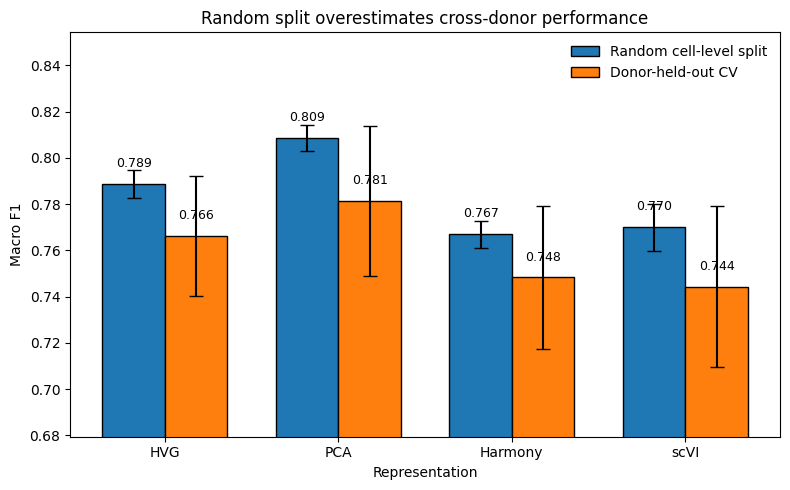

Saved: results/pbmc_no_batch/figures/panel_2B_random_vs_donor_cv_no_scanorama.png


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_dir = Path("results/pbmc_no_batch")  # change if needed
figures_dir = result_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

random_df = pd.read_csv(result_dir / "random_split" / "random_split_repeated_metrics.csv")
donor_df = pd.read_csv(result_dir / "donor_cv" / "metrics.csv")

rep_order = ["hvg", "pca", "harmony", "scvi"]
rep_labels = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
}

def clean_rep(x):
    return {
        "hvg": "hvg",
        "pca": "pca",
        "harmony": "harmony",
        "scvi": "scvi",
        "X_pca": "pca",
        "X_harmony": "harmony",
        "X_pca_harmony": "harmony",
        "X_scVI": "scvi",
    }.get(x, x)

random_df["rep_clean"] = random_df["representation"].map(clean_rep)
donor_df["rep_clean"] = donor_df["representation"].map(clean_rep)

random_summary = (
    random_df
    .groupby("rep_clean", as_index=False)
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        n_repeats=("repeat_seed", "nunique"),
    )
)

common_reps = [
    rep for rep in rep_order
    if rep in set(random_summary["rep_clean"]) and rep in set(donor_df["rep_clean"])
]

random_plot = random_summary.set_index("rep_clean").loc[common_reps]
donor_plot = donor_df.set_index("rep_clean").loc[common_reps]

x = np.arange(len(common_reps))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

bars_random = ax.bar(
    x - width / 2,
    random_plot["macro_f1_mean"],
    width,
    yerr=random_plot["macro_f1_std"],
    capsize=5,
    label="Random cell-level split",
    edgecolor="black",
)

bars_donor = ax.bar(
    x + width / 2,
    donor_plot["macro_f1_mean"],
    width,
    yerr=donor_plot["macro_f1_std"],
    capsize=5,
    label="Donor-held-out CV",
    edgecolor="black",
)

ax.set_xticks(x)
ax.set_xticklabels([rep_labels[r] for r in common_reps])
ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title("Random split overestimates cross-donor performance")
ax.legend(frameon=False)

ymax = max(
    (random_plot["macro_f1_mean"] + random_plot["macro_f1_std"]).max(),
    (donor_plot["macro_f1_mean"] + donor_plot["macro_f1_std"]).max(),
)
ymin = min(
    (random_plot["macro_f1_mean"] - random_plot["macro_f1_std"]).min(),
    (donor_plot["macro_f1_mean"] - donor_plot["macro_f1_std"]).min(),
)
ax.set_ylim(ymin - 0.03, ymax + 0.04)

for bars in [bars_random, bars_donor]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.006,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()

out_png = figures_dir / "panel_2B_random_vs_donor_cv_no_scanorama.png"
# plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")